# 15 — EDA fase 6: sociodemografía

**Pregunta guía:** ¿las condiciones sociodemográficas explican diferencias de incidencia entre distritos, y cuáles son redundantes?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura). Todo se calcula en memoria, con una fila por distrito.

**Diseño del análisis:**
- Las 15 `fraccion_*` solo se observan en 2017 y 2025; los años intermedios son interpolación lineal (fase 1). Por eso el análisis es de **corte transversal entre 65 distritos** (n bajo) y usa los valores observados: **2017** como principal y **2025** como sensibilidad.
- Desenlace: incidencia acumulada 2017-2024 por 100 000 hab. (casos / población media × 100 000). Se excluye 2025 por la ruptura de fuente.
- Cautelas:
  - **Falacia ecológica:** las relaciones son entre distritos, no entre personas.
  - **Costa/sierra como confusor:** la sierra (Ayabaca y Huancabamba, por provincia) es a la vez más rural y casi sin dengue, así que cada relación se repite **solo en la costa**. Como la provincia es una aproximación gruesa (Morropón tiene distritos andinos), se agrega una sensibilidad con los distritos **cálidos** (temperatura media ≥ 20 °C), que usa el clima del propio dataset.
  - Los distritos no son independientes (autocorrelación espacial, fase 4), así que los intervalos por bootstrap de distritos son optimistas.

Etiquetas: **Observación** · **Hipótesis** · **Implicación**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from src.eda.carga import cargar_integrado, OBJETIVO, columnas_socio
from src.eda.objetivo import tasa_100k
from src.eda.temporal import asignar_temporada
from src.eda.socio import vif, componentes_principales, spearman_bootstrap, limites_embudo
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
FASE = "fase6_sociodemografico"
SIERRA = ["Ayabaca", "Huancabamba"]
M = {}

df = cargar_integrado()
SOCIO = columnas_socio(df)
F = [c for c in SOCIO if c.startswith("fraccion_")]
corto = {c: c.removeprefix("fraccion_") for c in F}
anual = df.groupby(["ubigeo", "anio"])[SOCIO].first()
s17, s25 = anual.xs(2017, level="anio"), anual.xs(2025, level="anio")
geo = df.drop_duplicates("ubigeo").set_index("ubigeo")[["provincia", "distrito"]]
geo["distrito"] = geo["distrito"].str.replace(r"_s$", "", regex=True)
geo.loc[geo["distrito"].duplicated(keep=False), "distrito"] += " (" + geo["provincia"] + ")"
costa = ~geo["provincia"].isin(SIERRA)
# Sensibilidad: "costa cálida" por clima (temperatura media del periodo ≥ 20 °C), porque la provincia es una
# aproximación gruesa (hay distritos andinos en Morropón y distritos cálidos en Ayabaca).
temp_media_distrito = df.groupby("ubigeo")["temp_media"].mean()
calida = temp_media_distrito >= 20

h = df[df["anio"] <= 2024].groupby("ubigeo").agg(casos=(OBJETIVO, "sum"), pob=("poblacion", "mean"))
h["incidencia"] = tasa_100k(h["casos"], h["pob"])
h["log_inc"] = np.log1p(h["incidencia"])
M["n_distritos"], M["n_distritos_costa"], M["n_distritos_calidos_temp_ge_20"] = int(len(h)), int(costa.sum()), int(calida.sum())
M["costa_por_provincia_no_calidos"] = sorted(geo.loc[costa & ~calida, "distrito"])
M["sierra_por_provincia_calidos"] = sorted(geo.loc[~costa & calida, "distrito"])
print(f"{M['n_distritos']} distritos ({M['n_distritos_costa']} de costa por provincia; {M['n_distritos_calidos_temp_ge_20']} con temperatura media ≥ 20 °C).")
print("Costa por provincia pero < 20 °C:", M["costa_por_provincia_no_calidos"], "| sierra por provincia pero ≥ 20 °C:", M["sierra_por_provincia_calidos"])

65 distritos (47 de costa por provincia; 44 con temperatura media ≥ 20 °C).
Costa por provincia pero < 20 °C: ['Chalaco', 'Salitral (Morropón)', 'Santa Catalina de Mossa', 'Santo Domingo', 'Yamango'] | sierra por provincia pero ≥ 20 °C: ['Paimas', 'Suyo']


## 1. ¿Qué cambió entre 2017 y 2025 (los dos años observados)?

**Qué quiero saber:** cuánto se movió cada fracción entre los dos años observados. Si una variable cambió mucho, la interpolación lineal de los años intermedios es un supuesto fuerte, porque el cambio pudo ser brusco y no gradual.

In [2]:
cambio = pd.DataFrame({"mediana_2017": s17[F].median(), "mediana_2025": s25[F].median(), "rango_iqr_2017": s17[F].quantile(0.75) - s17[F].quantile(0.25),
                       "cambio_mediano": (s25[F] - s17[F]).median(),
                       "spearman_2017_vs_2025": [s17[c].corr(s25[c], method="spearman") for c in F]}).round(3)
cambio.index = [corto[c] for c in F]
M["cambio_2017_2025"] = {k: {kk: float(vv) for kk, vv in f.items()} for k, f in cambio.iterrows()}
M["variables_orden_distrital_estable_rho_ge_0_9"] = [k for k in cambio.index if cambio.loc[k, "spearman_2017_vs_2025"] >= 0.9]
M["variables_orden_distrital_inestable_rho_lt_0_8"] = [k for k in cambio.index if cambio.loc[k, "spearman_2017_vs_2025"] < 0.8]
M["cambio_mediano_sin_seguro"] = float(cambio.loc["sin_seguro", "cambio_mediano"])
print("Variables con orden distrital estable 2017→2025 (Spearman ≥ 0.9):", len(M["variables_orden_distrital_estable_rho_ge_0_9"]), "de", len(F))
cambio.sort_values("cambio_mediano")

Variables con orden distrital estable 2017→2025 (Spearman ≥ 0.9): 8 de 15


,mediana_2017,mediana_2025,rango_iqr_2017,cambio_mediano,spearman_2017_vs_2025
sin_seguro,0.157,0.018,0.095,-0.135,0.859
piso_tierra,0.667,0.593,0.429,-0.065,0.979
pared_precaria,0.673,0.574,0.465,-0.054,0.980
menores_15,0.305,0.260,0.052,-0.045,0.934
hogares_lena,0.537,0.503,0.644,-0.041,0.976
analfabeta_15_mas,0.098,0.077,0.113,-0.017,0.985
sin_saneamiento,0.138,0.126,0.218,-0.008,0.897
agua_red,0.774,0.738,0.287,-0.005,0.578
mujeres,0.497,0.499,0.011,-0.000,0.686
rural,0.230,0.167,0.970,0.000,0.971


**Observación.**
- Los niveles cambian poco en la mayoría de las fracciones, pero algunas cambiaron mucho: **sin seguro** cae fuertemente y la tenencia de **celular** sube (tabla).
- El orden de los distritos se mantiene (Spearman ≥ 0.9) solo en 8 de 15 fracciones. En `agua_red`, `mujeres` y `alumbrado_red` el orden cambia bastante entre 2017 y 2025 (lista de inestables arriba), algo raro en tan pocos años.

**Hipótesis.**
- La caída de "sin seguro" podría reflejar la ampliación de la cobertura del seguro público. La interpolación lineal la reparte como si hubiera sido gradual.
- El cambio de orden en `agua_red`, `mujeres` y `alumbrado_red` podría deberse a diferencias de fuente o de definición entre los dos años.
- Ninguna de las dos es verificable con el repo; se registran como posibles problemas de datos.

Nota: `mujeres` varía muy poco entre distritos, así que un Spearman menor entre años es esperable aunque la fuente sea consistente. La sospecha de fuente se sostiene sobre todo para `agua_red` y, en menor medida, para `alumbrado_red`.

**Implicación.**
- Las fracciones sirven para ordenar distritos, no como series temporales. En las variables inestables, incluso el orden entre distritos depende del año elegido.
- **Fuga de información:** los valores interpolados de 2018-2024 se construyen con el dato de 2025, y 2025 es posterior a casi todo el periodo. Un modelo con validación temporal debería usar un año observado fijo **anterior** al periodo de prueba (2017).

## 2. Colinealidad: ¿cuántas dimensiones hay realmente?

**Qué quiero saber:** cuánto se repiten las 15 fracciones (2017). Se mide con Spearman entre pares, VIF y componentes principales sobre las variables estandarizadas.

Pares con |rho| ≥ 0.85: 20. Variables con VIF > 10: 5 de 15.
Varianza explicada: {'CP1': 0.613, 'CP2': 0.124, 'CP3': 0.073}
Cargas CP1: {'piso_tierra': -0.315, 'hogares_lena': -0.313, 'analfabeta_15_mas': -0.301, 'pared_precaria': -0.301, 'rural': -0.252, 'sin_saneamiento': -0.228, 'menores_15': -0.182, 'mujeres': 0.047, 'agua_cisterna': 0.16, 'agua_red': 0.215, 'alumbrado_red': 0.237, 'sin_seguro': 0.24, 'desague_red': 0.302, 'hogares_celular': 0.308, 'hogares_refrigeradora': 0.315}
Cargas CP2: {'alumbrado_red': -0.389, 'agua_red': -0.244, 'pared_precaria': -0.215, 'rural': -0.162, 'hogares_lena': -0.069, 'piso_tierra': -0.051, 'desague_red': -0.001, 'analfabeta_15_mas': 0.002, 'hogares_celular': 0.032, 'hogares_refrigeradora': 0.065, 'mujeres': 0.268, 'sin_seguro': 0.297, 'sin_saneamiento': 0.383, 'agua_cisterna': 0.401, 'menores_15': 0.487}


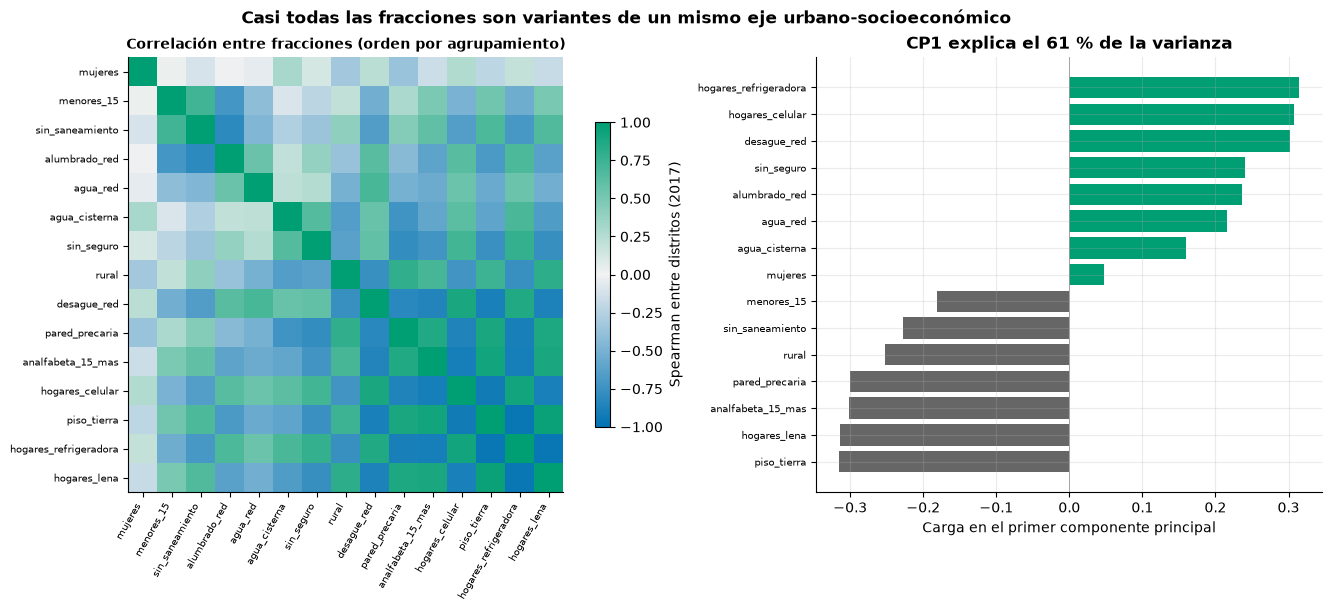

,piso_tierra,hogares_lena,hogares_refrigeradora,pared_precaria,desague_red,hogares_celular,analfabeta_15_mas,sin_seguro,rural,alumbrado_red,sin_saneamiento,agua_red,menores_15,agua_cisterna,mujeres
vif,33.2,22.6,20.3,18.4,10.5,7.8,6.7,5.4,5.2,4.5,3.9,3.1,3.1,2.0,1.7


In [3]:
corr = s17[F].corr(method="spearman")
orden = [F[i] for i in leaves_list(linkage(squareform(1 - corr.abs().to_numpy(), checks=False), "average"))]
iu = np.triu_indices(len(F), 1)
pares = [(corto[F[i]], corto[F[j]], round(float(corr.iloc[i, j]), 2)) for i, j in zip(*iu) if abs(corr.iloc[i, j]) >= 0.85]
M["pares_abs_rho_ge_0_85"] = [list(p) for p in pares]
v = vif(s17[F]).rename(index=corto).round(1)
M["vif_2017"] = {k: float(x) for k, x in v.items()}
M["n_variables_vif_mayor_10"] = int((v > 10).sum())
var, cargas, puntajes = componentes_principales(s17[F], n=3)
# Orientación: CP1 positivo = más urbano (carga positiva en desagüe por red)
if cargas.loc["fraccion_desague_red", "CP1"] < 0:
    cargas["CP1"], puntajes["CP1"] = -cargas["CP1"], -puntajes["CP1"]
M["varianza_explicada_cp"] = {k: round(float(x), 3) for k, x in var.items()}
M["cargas_cp1"] = {corto[k]: round(float(x), 3) for k, x in cargas["CP1"].sort_values().items()}
M["cargas_cp2"] = {corto[k]: round(float(x), 3) for k, x in cargas["CP2"].sort_values().items()}
print(f"Pares con |rho| ≥ 0.85: {len(pares)}. Variables con VIF > 10: {M['n_variables_vif_mayor_10']} de {len(F)}.")
print("Varianza explicada:", M["varianza_explicada_cp"])
print("Cargas CP1:", M["cargas_cp1"])
print("Cargas CP2:", M["cargas_cp2"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.25, 1]}, layout="constrained")
cmap = LinearSegmentedColormap.from_list("div", [COLORES["clima"], "#f2f2f2", COLORES["socio"]])
m = corr.loc[orden, orden]
im = axes[0].imshow(m.to_numpy(), cmap=cmap, vmin=-1, vmax=1)
axes[0].set_xticks(range(len(orden)), [corto[c] for c in orden], rotation=60, ha="right", fontsize=7)
axes[0].set_yticks(range(len(orden)), [corto[c] for c in orden], fontsize=7)
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], shrink=0.7, label="Spearman entre distritos (2017)")
axes[0].set_title("Correlación entre fracciones (orden por agrupamiento)", fontsize=10)
c1 = cargas["CP1"].rename(index=corto).sort_values()
axes[1].barh(range(len(c1)), c1.to_numpy(), color=[COLORES["socio"] if x > 0 else COLORES["referencia"] for x in c1])
axes[1].set_yticks(range(len(c1)), c1.index, fontsize=7)
axes[1].axvline(0, color="#999999", lw=0.6)
axes[1].set(xlabel="Carga en el primer componente principal", title=f"CP1 explica el {var['CP1'] * 100:.0f} % de la varianza")
fig.suptitle("Casi todas las fracciones son variantes de un mismo eje urbano-socioeconómico", fontweight="bold")
guardar_figura(fig, FASE, "01_colinealidad")
plt.show()
v.sort_values(ascending=False).to_frame().T

**Observación.** Las fracciones forman un bloque muy correlacionado: muchos pares con |rho| ≥ 0.85, VIF > 10 en varias de ellas y un primer componente que explica por sí solo la mayor parte de la varianza (cifras arriba). Ese componente opone los hogares con refrigeradora, celular, desagüe, alumbrado y agua de red (y, llamativamente, la falta de seguro) a la ruralidad, el piso de tierra, las paredes precarias, el uso de leña y el analfabetismo. Es un eje **urbano-socioeconómico**. `mujeres` es la que menos carga en él. El segundo componente, más pequeño, agrupa menores de 15 años, agua de cisterna, falta de saneamiento y falta de seguro.
**Implicación.** Meter las 15 fracciones al modelo añade colinealidad sin información nueva. Alcanza con el puntaje del primer componente (calculado solo con entrenamiento) o con 2-3 variables representativas (por ejemplo, `hogares_refrigeradora` o `desague_red`, `rural`, `agua_red`). Recomendación, no decisión.

## 3. ¿Se relacionan con la incidencia? En toda la región y solo en la costa

**Qué quiero saber:** la correlación de Spearman de cada fracción (2017) y del CP1 con `log1p(incidencia acumulada 2017-2024)`, con un IC95 % por bootstrap de distritos (2 000 réplicas, semilla 42). Se calcula en todos los distritos y solo en los de costa. Sensibilidad: los mismos valores con las fracciones de 2025.

CP1 según la definición de zona: {'costa_provincia': {'rho': 0.386, 'ic95_inf': 0.069, 'ic95_sup': 0.632}, 'calidos_temp_ge_20': {'rho': 0.355, 'ic95_inf': 0.051, 'ic95_sup': 0.626}, 'costa_y_calidos': {'rho': 0.277, 'ic95_inf': -0.061, 'ic95_sup': 0.56, 'n': 42}}
Cálidos (≥ 20 °C), IC95 % excluye 0: ['rural', 'hogares_lena', 'sin_saneamiento', 'menores_15', 'mujeres', 'alumbrado_red', 'agua_red', 'desague_red', 'CP1', 'hogares_refrigeradora']
CP1 en costa, desenlace acumulado sin cada temporada: {2017: 0.309, 2023: 0.501, 2024: 0.295}
Solo costa, IC95 % excluye 0: ['rural', 'hogares_lena', 'piso_tierra', 'alumbrado_red', 'agua_red', 'desague_red', 'CP1', 'hogares_refrigeradora']
Mediana de |rho|: todos vs costa: [0.617, 0.314]


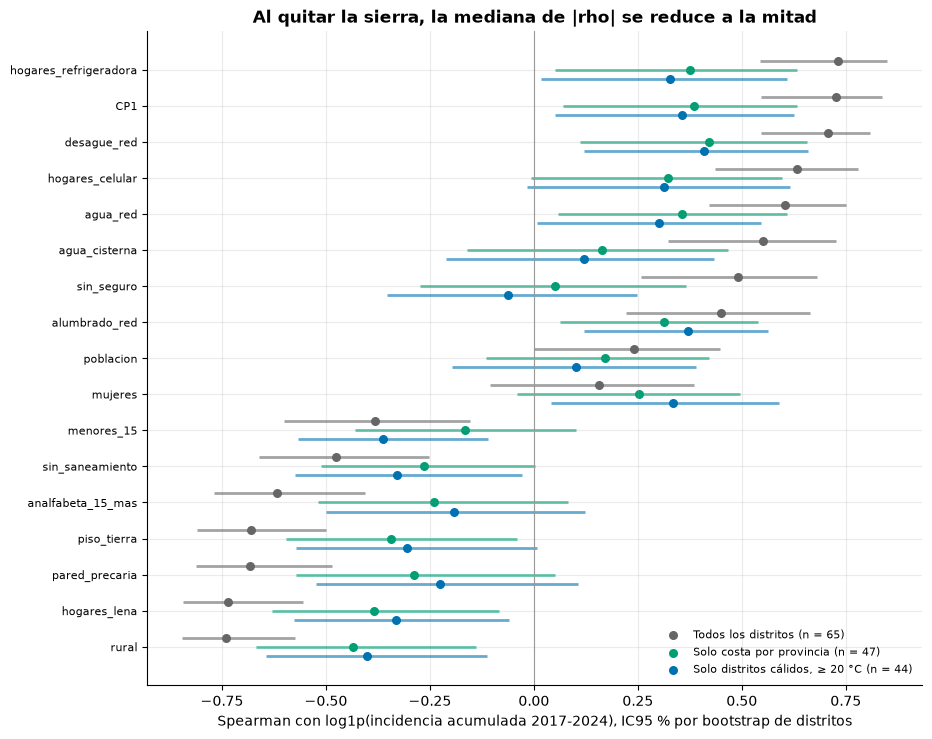

,rho_todos,ic_inf_todos,ic_sup_todos,rho_costa,ic_inf_costa,ic_sup_costa,rho_costa_2025,rho_calidos,ic_inf_calidos,ic_sup_calidos
rural,-0.741,-0.845,-0.575,-0.434,-0.669,-0.138,-0.324,-0.401,-0.644,-0.112
hogares_lena,-0.736,-0.844,-0.554,-0.384,-0.629,-0.083,-0.332,-0.331,-0.576,-0.060
pared_precaria,-0.682,-0.812,-0.486,-0.289,-0.571,0.050,-0.285,-0.225,-0.524,0.107
piso_tierra,-0.680,-0.809,-0.500,-0.344,-0.595,-0.040,-0.330,-0.305,-0.571,0.007
analfabeta_15_mas,-0.617,-0.768,-0.407,-0.240,-0.518,0.082,-0.259,-0.192,-0.501,0.124
sin_saneamiento,-0.475,-0.661,-0.251,-0.265,-0.512,0.003,-0.337,-0.330,-0.575,-0.029
menores_15,-0.383,-0.600,-0.153,-0.165,-0.430,0.102,-0.116,-0.363,-0.567,-0.110
mujeres,0.157,-0.105,0.384,0.252,-0.040,0.496,0.233,0.335,0.042,0.590
poblacion,0.241,-0.000,0.448,0.171,-0.114,0.421,0.196,0.102,-0.198,0.390
alumbrado_red,0.449,0.221,0.665,0.314,0.063,0.539,0.124,0.370,0.120,0.562


In [4]:
X17 = s17[F].rename(columns=corto).assign(CP1=puntajes["CP1"], poblacion=s17["poblacion"])
_, carg25, punt25 = componentes_principales(s25[F], n=1)
if carg25.loc["fraccion_desague_red", "CP1"] < 0:
    punt25["CP1"] = -punt25["CP1"]
X25 = s25[F].rename(columns=corto).assign(CP1=punt25["CP1"], poblacion=s25["poblacion"])
filas = {}
for c in X17.columns:
    t = spearman_bootstrap(X17[c], h["log_inc"])
    k = spearman_bootstrap(X17.loc[costa, c], h.loc[costa, "log_inc"])
    filas[c] = {"rho_todos": t["rho"], "ic_inf_todos": t["ic95_inf"], "ic_sup_todos": t["ic95_sup"],
                "rho_costa": k["rho"], "ic_inf_costa": k["ic95_inf"], "ic_sup_costa": k["ic95_sup"],
                "rho_costa_2025": X25.loc[costa, c].corr(h.loc[costa, "log_inc"], method="spearman")}
    q = spearman_bootstrap(X17.loc[calida, c], h.loc[calida, "log_inc"])
    filas[c].update({"rho_calidos": q["rho"], "ic_inf_calidos": q["ic95_inf"], "ic_sup_calidos": q["ic95_sup"]})
rel = pd.DataFrame(filas).T.round(3).sort_values("rho_todos")
M["spearman_con_log_incidencia"] = {k: {kk: float(vv) for kk, vv in f.items()} for k, f in rel.iterrows()}
M["variables_ic_costa_excluye_0"] = [k for k in rel.index if rel.loc[k, "ic_inf_costa"] > 0 or rel.loc[k, "ic_sup_costa"] < 0]
M["variables_ic_calidos_excluye_0"] = [k for k in rel.index if rel.loc[k, "ic_inf_calidos"] > 0 or rel.loc[k, "ic_sup_calidos"] < 0]
# Sensibilidad del desenlace acumulado: CP1 vs incidencia acumulada 2017-2024 sin cada temporada grande (costa)
df["temporada"] = asignar_temporada(df["anio"], df["semana"], 35)
loso = {}
for t in [2017, 2023, 2024]:
    g = df[(df["anio"] <= 2024) & (df["temporada"] != t)].groupby("ubigeo").agg(c=(OBJETIVO, "sum"), p=("poblacion", "mean"))
    loso[int(t)] = round(float(X17.loc[costa, "CP1"].corr(np.log1p(tasa_100k(g["c"], g["p"]))[costa], method="spearman")), 3)
M["cp1_costa_rho_sin_cada_temporada"] = loso
# Tercera definición: costa por provincia Y cálida (excluye los andinos de Morropón y los cálidos de Ayabaca)
costa_calida = costa & calida
M["n_distritos_costa_y_calidos"] = int(costa_calida.sum())
M["cp1_rho_por_definicion_de_zona"] = {
    "costa_provincia": {k: round(float(rel.loc["CP1", c]), 3) for k, c in [("rho", "rho_costa"), ("ic95_inf", "ic_inf_costa"), ("ic95_sup", "ic_sup_costa")]},
    "calidos_temp_ge_20": {k: round(float(rel.loc["CP1", c]), 3) for k, c in [("rho", "rho_calidos"), ("ic95_inf", "ic_inf_calidos"), ("ic95_sup", "ic_sup_calidos")]},
    "costa_y_calidos": {k: (round(v, 3) if isinstance(v, float) else v) for k, v in spearman_bootstrap(X17.loc[costa_calida, "CP1"], h.loc[costa_calida, "log_inc"]).items()},
}
print("CP1 según la definición de zona:", M["cp1_rho_por_definicion_de_zona"])
print("Cálidos (≥ 20 °C), IC95 % excluye 0:", M["variables_ic_calidos_excluye_0"])
print("CP1 en costa, desenlace acumulado sin cada temporada:", loso)
M["mediana_abs_rho_todos_vs_costa"] = [round(float(rel["rho_todos"].abs().median()), 3), round(float(rel["rho_costa"].abs().median()), 3)]
print("Solo costa, IC95 % excluye 0:", M["variables_ic_costa_excluye_0"])
print("Mediana de |rho|: todos vs costa:", M["mediana_abs_rho_todos_vs_costa"])

fig, ax = plt.subplots(figsize=(10, 8.5))
y = np.arange(len(rel)) * 1.0
ax.hlines(y + 0.25, rel["ic_inf_todos"], rel["ic_sup_todos"], color=COLORES["referencia"], lw=2, alpha=0.6)
ax.scatter(rel["rho_todos"], y + 0.25, color=COLORES["referencia"], s=30, label=f"Todos los distritos (n = {M['n_distritos']})")
ax.hlines(y, rel["ic_inf_costa"], rel["ic_sup_costa"], color=COLORES["socio"], lw=2, alpha=0.6)
ax.scatter(rel["rho_costa"], y, color=COLORES["socio"], s=30, label=f"Solo costa por provincia (n = {M['n_distritos_costa']})")
ax.hlines(y - 0.25, rel["ic_inf_calidos"], rel["ic_sup_calidos"], color=COLORES["clima"], lw=2, alpha=0.6)
ax.scatter(rel["rho_calidos"], y - 0.25, color=COLORES["clima"], s=30, label=f"Solo distritos cálidos, ≥ 20 °C (n = {M['n_distritos_calidos_temp_ge_20']})")
ax.axvline(0, color="#999999", lw=0.8)
ax.set_yticks(y, rel.index, fontsize=8)
ax.set(xlabel="Spearman con log1p(incidencia acumulada 2017-2024), IC95 % por bootstrap de distritos",
       title="Al quitar la sierra, la mediana de |rho| se reduce a la mitad")
ax.legend(loc="lower right", fontsize=8)
guardar_figura(fig, FASE, "02_correlacion_con_incidencia")
plt.show()
rel

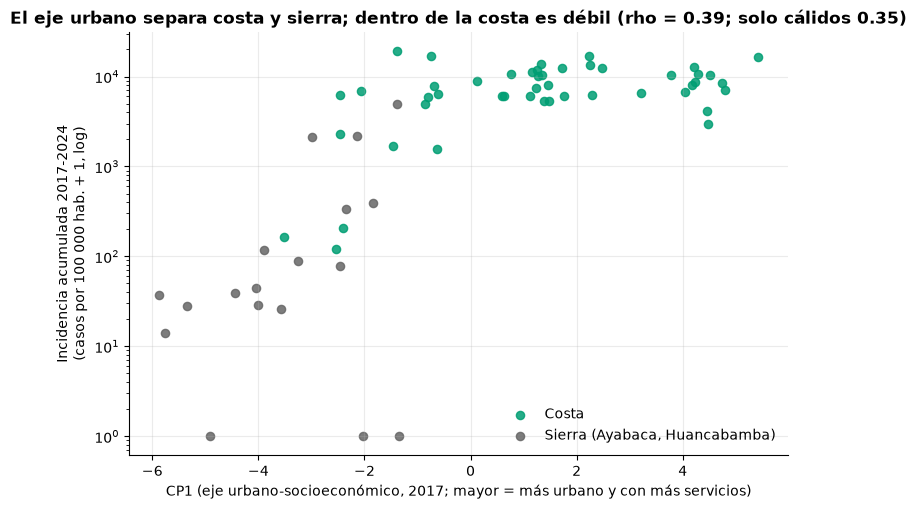

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for es_costa, color, lab in [(True, COLORES["socio"], "Costa"), (False, COLORES["referencia"], "Sierra (Ayabaca, Huancabamba)")]:
    m = costa == es_costa
    ax.scatter(X17.loc[m, "CP1"], h.loc[m, "incidencia"] + 1, s=35, color=color, alpha=0.85, label=lab)
ax.set_yscale("log")
ax.set(xlabel="CP1 (eje urbano-socioeconómico, 2017; mayor = más urbano y con más servicios)",
       ylabel="Incidencia acumulada 2017-2024\n(casos por 100 000 hab. + 1, log)",
       title=f"El eje urbano separa costa y sierra; dentro de la costa es débil (rho = {rel.loc['CP1', 'rho_costa']:.2f}; solo cálidos {rel.loc['CP1', 'rho_calidos']:.2f})")
ax.legend(loc="lower right")
guardar_figura(fig, FASE, "03_cp1_vs_incidencia")
plt.show()

**Observación.**
- Con todos los distritos, varias fracciones se correlacionan fuertemente con la incidencia: más urbano y con más servicios, más incidencia.
- Solo en la costa por provincia, esas correlaciones **se reducen** (la mediana de |rho| baja a la mitad; cifras arriba).
- La correlación del CP1 dentro de la zona cálida **depende de cómo se defina la zona** (tabla de definiciones arriba):
  - con los distritos cálidos (≥ 20 °C, que incluye dos de Ayabaca y excluye cinco andinos de Morropón), es similar a la de la costa por provincia;
  - con costa y cálidos a la vez, es menor y su intervalo incluye el 0.
- La correlación del CP1 con la incidencia acumulada también cambia bastante al quitar una temporada grande (cifras arriba).
- Conclusión: buena parte de la relación es la separación entre zonas frías y cálidas, que confunde condiciones sociales con clima y altitud. Dentro de la zona cálida la asociación es **débil y sensible** a la definición de zona y a qué temporadas se incluyan. Con las fracciones de 2025 los resultados en la costa son parecidos (columna `rho_costa_2025`).
**Hipótesis.** Dentro de la costa, una asociación positiva con lo urbano podría reflejar mayor densidad o conectividad, o mejor acceso a diagnóstico y notificación, y no necesariamente mayor riesgo biológico. El dataset no permite distinguirlo, y es una relación ecológica, entre distritos.
**Implicación.** La sociodemografía aporta sobre todo el **nivel** de cada distrito, que el modelo también puede tomar de la historia propia de casos. Su valor agregado probablemente sea mayor en distritos con poca historia. Conviene usarla como pocas variables estáticas por distrito, no como series.

## 4. ¿La relación es estable entre temporadas de brote?

**Qué quiero saber:** si la correlación del CP1 (2017) con la incidencia de cada temporada (semanas 35 a 34; fase 3) se mantiene, en la costa. Se muestran todas las temporadas completas y la 2017 marcada como parcial (semanas 1-34). En las temporadas de silencio la mayoría de los distritos tiene cero casos (columna). Si la correlación cambia de signo o de magnitud, no sería un rasgo estable del distrito.

In [6]:
por_temp = {}
for t in range(2017, 2026):
    g = df[df["temporada"] == t].groupby("ubigeo").agg(c=(OBJETIVO, "sum"), p=("poblacion", "mean"))
    li = np.log1p(tasa_100k(g["c"], g["p"]))
    r = spearman_bootstrap(X17.loc[costa, "CP1"], li[costa])
    por_temp[int(t)] = {k: round(x, 3) if isinstance(x, float) else x for k, x in r.items()}
    por_temp[int(t)]["distritos_costa_en_cero"] = int((g.loc[costa[costa].index, "c"] == 0).sum())
    por_temp[int(t)]["parcial"] = t == 2017
M["cp1_vs_incidencia_por_temporada_costa"] = por_temp
pd.DataFrame(por_temp).T

,rho,ic95_inf,ic95_sup,n,distritos_costa_en_cero,parcial
2017,0.276,-0.021,0.534,47,3,True
2018,0.233,-0.087,0.528,47,11,False
2019,0.458,0.185,0.669,47,33,False
2020,0.252,-0.087,0.534,47,30,False
2021,0.194,-0.106,0.487,47,13,False
2022,0.062,-0.246,0.356,47,4,False
2023,0.207,-0.129,0.497,47,0,False
2024,0.375,0.082,0.617,47,0,False
2025,0.146,-0.161,0.437,47,6,False


**Observación.** En la costa, la correlación del eje urbano con la incidencia de cada temporada varía mucho de una temporada a otra (tabla). En las temporadas de silencio, con muchos distritos en cero, la correlación mide sobre todo quién registra algún caso, no la intensidad del brote.
**Implicación.** Es una asociación débil e inestable entre temporadas: la utilidad del eje urbano como predictor fijo es limitada, y el modelo debería apoyarse más en la historia reciente del distrito.

## 5. Población como exposición: ¿las tasas de los distritos pequeños son confiables?

**Qué quiero saber:** (a) si la incidencia depende del tamaño del distrito y (b) cuánto se dispersan las tasas por puro azar en los distritos pequeños. Para (b) se usa un **gráfico de embudo**: los límites del 95 % y del 99.8 % que tendría la tasa si todos los distritos compartieran la tasa de la costa (aproximación de Poisson). Se usa la costa porque la sierra tiene una tasa de base muy distinta.

Sobredispersión (phi) = 587.4; fuera del 99.8 % ajustado: 2.1 %.
Tasa anual media de la costa: 1174.3 por 100 000 hab. Distritos de costa fuera del límite 99.8 % (Poisson): 97.9 %. Población media (mín, mediana, máx): [1249, 11717, 192874].


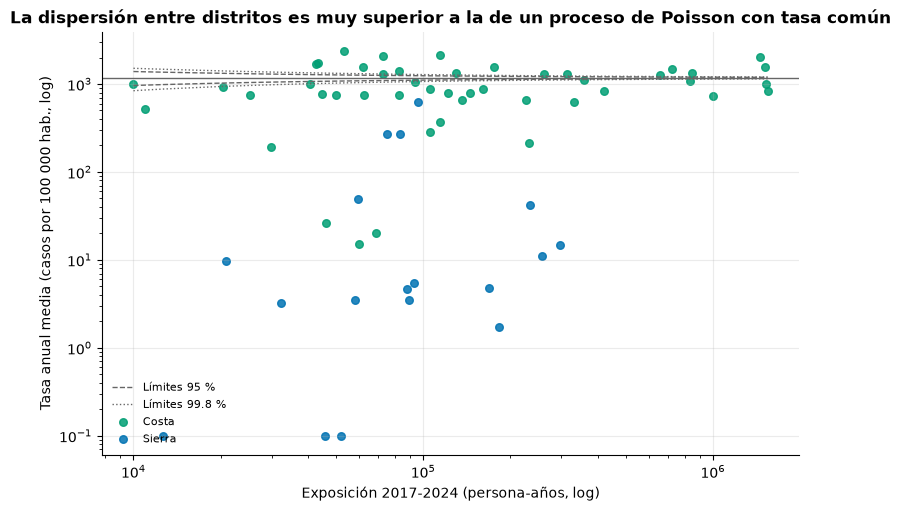

In [7]:
anios = df.loc[df["anio"] <= 2024, "anio"].nunique()
exp = h["pob"] * anios                                     # persona-años aproximados 2017-2024
tasa_costa = h.loc[costa, "casos"].sum() / exp[costa].sum()
lo95, hi95 = limites_embudo(exp.to_numpy(), tasa_costa, 1.96)
lo998, hi998 = limites_embudo(exp.to_numpy(), tasa_costa, 3.09)
tasa_anual = h["casos"] / exp
fuera998 = costa & ((tasa_anual < lo998) | (tasa_anual > hi998))
# Ajuste por sobredispersión (cuasi-Poisson): phi = chi² de Pearson / (n - 1) en la costa; límites ensanchados por sqrt(phi)
esp = tasa_costa * exp[costa]
phi = float((((h.loc[costa, "casos"] - esp) ** 2) / esp).sum() / (costa.sum() - 1))
lo998_od = np.clip(tasa_costa - 3.09 * np.sqrt(phi * tasa_costa / exp), 0, None)
hi998_od = tasa_costa + 3.09 * np.sqrt(phi * tasa_costa / exp)
fuera_od = costa & ((tasa_anual < lo998_od) | (tasa_anual > hi998_od))
M["phi_sobredispersion_costa"] = round(phi, 1)
M["pct_distritos_costa_fuera_998_ajustado_sobredispersion"] = round(float(fuera_od.sum() / costa.sum() * 100), 1)
M["tasa_anual_costa_por_100k"] = round(float(tasa_costa * 1e5), 1)
M["pct_distritos_costa_fuera_limite_998"] = round(float(fuera998.sum() / costa.sum() * 100), 1)
M["spearman_poblacion_vs_log_incidencia"] = {"todos": round(float(rel.loc["poblacion", "rho_todos"]), 3), "costa": round(float(rel.loc["poblacion", "rho_costa"]), 3)}
M["poblacion_media_min_mediana_max"] = [int(h["pob"].min()), int(h["pob"].median()), int(h["pob"].max())]
print(f"Sobredispersión (phi) = {M['phi_sobredispersion_costa']}; fuera del 99.8 % ajustado: {M['pct_distritos_costa_fuera_998_ajustado_sobredispersion']} %.")
print(f"Tasa anual media de la costa: {M['tasa_anual_costa_por_100k']} por 100 000 hab. Distritos de costa fuera del límite 99.8 % (Poisson): "
      f"{M['pct_distritos_costa_fuera_limite_998']} %. Población media (mín, mediana, máx): {M['poblacion_media_min_mediana_max']}.")

fig, ax = plt.subplots(figsize=(9, 5.5))
orden_e = np.argsort(exp.to_numpy())
xs = exp.to_numpy()[orden_e]
for lo, hi, ls, lab in [(lo95, hi95, "--", "Límites 95 %"), (lo998, hi998, ":", "Límites 99.8 %")]:
    ax.plot(xs, hi[orden_e] * 1e5, color=COLORES["referencia"], ls=ls, lw=1, label=lab)
    ax.plot(xs, np.maximum(lo[orden_e] * 1e5, 0.1), color=COLORES["referencia"], ls=ls, lw=1)
ax.axhline(tasa_costa * 1e5, color=COLORES["referencia"], lw=1)
for es_costa, color, lab in [(True, COLORES["socio"], "Costa"), (False, COLORES["clima"], "Sierra")]:
    m = (costa == es_costa).to_numpy()
    ax.scatter(exp[m], tasa_anual[m] * 1e5 + 0.1, s=30, color=color, alpha=0.85, label=lab)
ax.set(xscale="log", yscale="log", xlabel="Exposición 2017-2024 (persona-años, log)",
       ylabel="Tasa anual media (casos por 100 000 hab., log)",
       title="La dispersión entre distritos es muy superior a la de un proceso de Poisson con tasa común")
ax.legend(loc="lower left", fontsize=8)
guardar_figura(fig, FASE, "04_embudo_poblacion")
plt.show()

**Observación.**
- El tamaño de la población (de 2017, en la tabla de la sección 3) tiene una relación débil con la incidencia (cifras arriba).
- En el embudo, casi todos los distritos de costa caen fuera de los límites del 99.8 % de un Poisson con tasa común: la heterogeneidad es muy superior a la de Poisson. Pero un proceso epidémico está muy sobredisperso (fase 2).
- Con límites ajustados por sobredispersión (cuasi-Poisson, phi arriba), casi ningún distrito queda fuera.

**Hipótesis.** Las diferencias entre distritos pueden reflejar riesgo, pero también diferencias de notificación o de acceso. El embudo no las distingue.
**Implicación.** Las tasas de los distritos pequeños son más ruidosas, y la variabilidad entre distritos es grande. Si el objetivo se expresa como tasa, conviene suavizar o ponderar las tasas de los distritos chicos (o usar la población como exposición en un modelo de conteo). Recomendación para feature engineering.

In [8]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase6_sociodemografico.json
